# 03 — Moving Averages & Crossovers

## What you'll learn
- What a **simple moving average (SMA)** is and why its window length trades smoothness for delay.
- How an **exponential moving average (EMA)** differs: it weights recent bars more, so it turns sooner.
- Why the **200-day** line looks flat and what that means for trend reading.
- How to read a **golden cross** (50-day above 200-day) and a **death cross** (50-day below 200-day).
- What crossovers *do* and *do not* tell you (they lag, and they whipsaw in sideways markets).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.indicators import sma, ema

sns.set_theme(style="whitegrid")

# One place to swap the symbol / window.
ticker = "AAPL"
period = "1y"


## The idea in one sentence

A moving average replaces each day's price with the **average of the last N days**. It is a
low-pass filter: the noise (daily jitter) averages out, the trend (slow drift) survives.

$$\text{SMA}_t(N) = \frac{1}{N}\sum_{i=0}^{N-1} \text{Close}_{t-i}$$

We always use the **adjusted close** (`price_series`), because splits and dividends would
otherwise create fake jumps that the average would smear across the window.

## 1. Price with three SMAs overlaid

The classic trio is **20 / 50 / 200** days:

- **20-day** (~1 trading month): fast, follows short swings, used for short-term timing.
- **50-day** (~1 quarter): the medium trend most swing traders watch.
- **200-day** (~10 months): the slow "is this a bull or bear market?" line.

Watch the **200-day**: over a 1-year window it is not even defined until day 200, and it moves
only a little each day because each new price is diluted by 199 old ones. That flatness is the
point — it is a *trend filter*, not a timing signal.


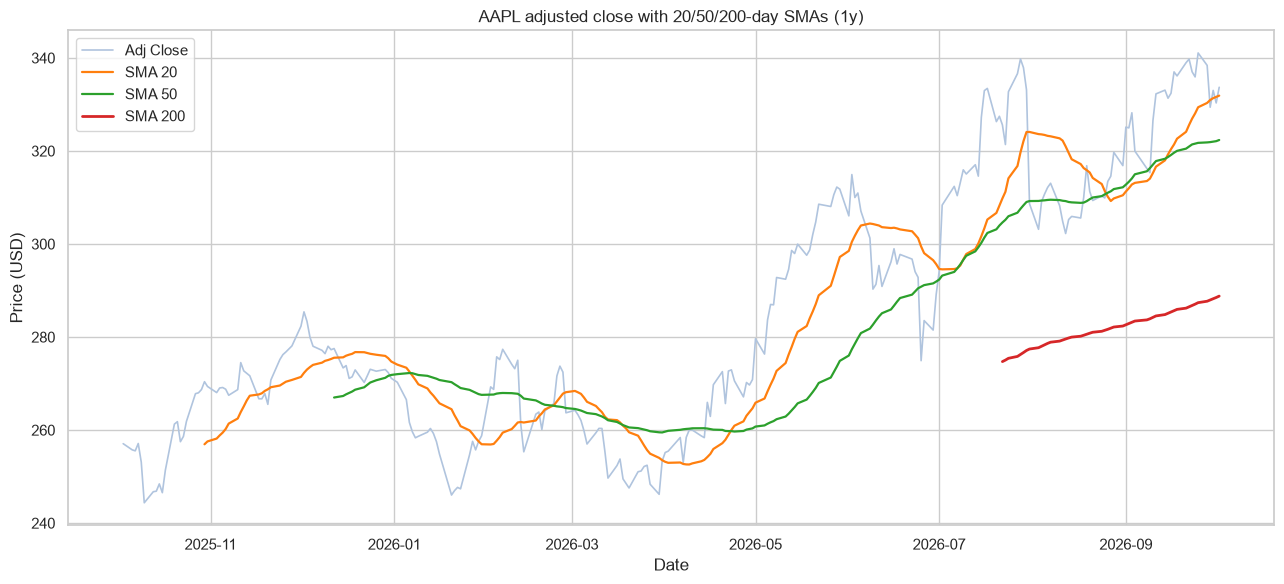

SMA200 non-NaN bars: 52 of 251


In [2]:
df = get_history(ticker, period=period)
close = price_series(df)

sma20 = sma(close, 20)
sma50 = sma(close, 50)
sma200 = sma(close, 200)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(close.index, close, color="lightsteelblue", linewidth=1.2, label="Adj Close")
ax.plot(close.index, sma20, color="tab:orange", linewidth=1.6, label="SMA 20")
ax.plot(close.index, sma50, color="tab:green", linewidth=1.6, label="SMA 50")
ax.plot(close.index, sma200, color="tab:red", linewidth=2.0, label="SMA 200")
ax.set_title(f"{ticker} adjusted close with 20/50/200-day SMAs ({period})")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("SMA200 non-NaN bars:", int(sma200.notna().sum()), "of", len(close))


## 2. EMA vs SMA — same idea, different memory

An **EMA** applies a decaying weight: the most recent price gets weight $\alpha$, the one
before gets $\alpha(1-\alpha)$, and so on, with $\alpha = 2/(\text{span}+1)$.

$$\text{EMA}_t = \alpha \cdot \text{Close}_t + (1-\alpha)\,\text{EMA}_{t-1}$$

| | SMA | EMA |
|---|---|---|
| Weighting | every bar in the window equal | recent bars heavier |
| Reaction to a turn | slow (waits for the window to roll) | **fast** |
| Noise | very smooth | slightly jumpier |

On the chart below, the orange EMA hugs price more tightly and turns earlier than the green SMA
of the same length — that extra responsiveness is exactly why traders pick one or the other.


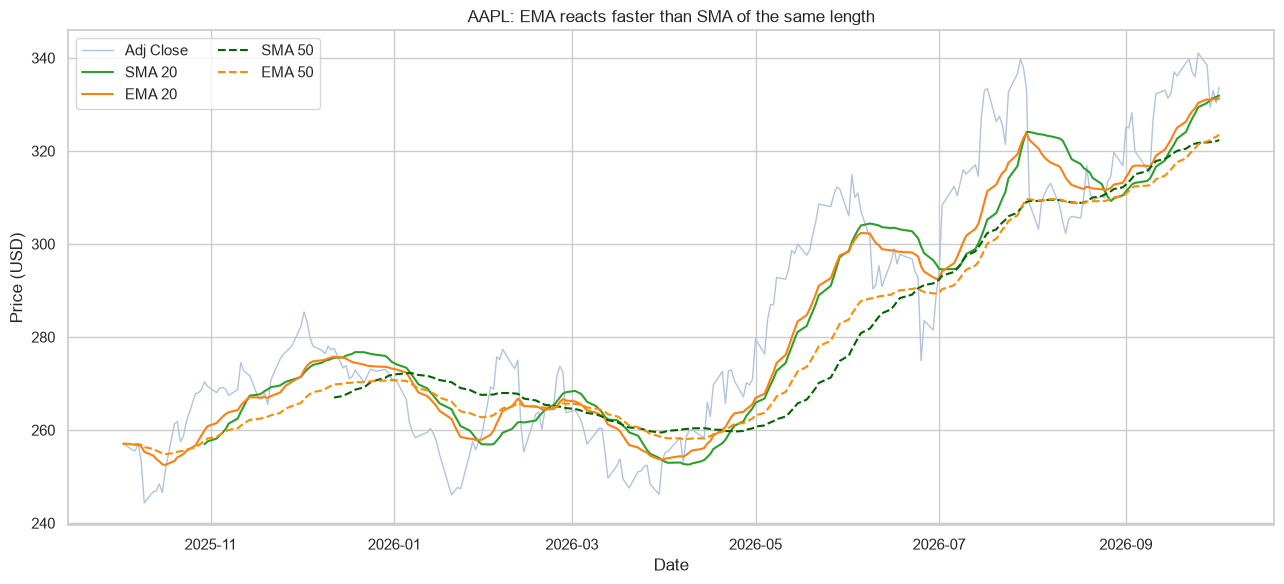

In [3]:
ema20 = ema(close, 20)
ema50 = ema(close, 50)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(close.index, close, color="lightsteelblue", linewidth=1.0, label="Adj Close")
ax.plot(close.index, sma(close, 20), color="tab:green", linewidth=1.5, label="SMA 20")
ax.plot(close.index, ema20, color="tab:orange", linewidth=1.5, label="EMA 20")
ax.plot(close.index, sma(close, 50), color="darkgreen", linewidth=1.5, linestyle="--", label="SMA 50")
ax.plot(close.index, ema50, color="darkorange", linewidth=1.5, linestyle="--", label="EMA 50")
ax.set_title(f"{ticker}: EMA reacts faster than SMA of the same length")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best", ncol=2)
plt.tight_layout()
plt.show()


## 3. How window length controls smoothness

Below we plot **5, 20 and 100-day** SMAs on a small-multiple panel. Short windows track every
wiggle; long windows are nearly a straight line. There is no "correct" window — it is a dial:

- short window → more signals, more false alarms;
- long window → fewer signals, more delay.

Pick the window from the **holding period** you care about: days → short, months → long.


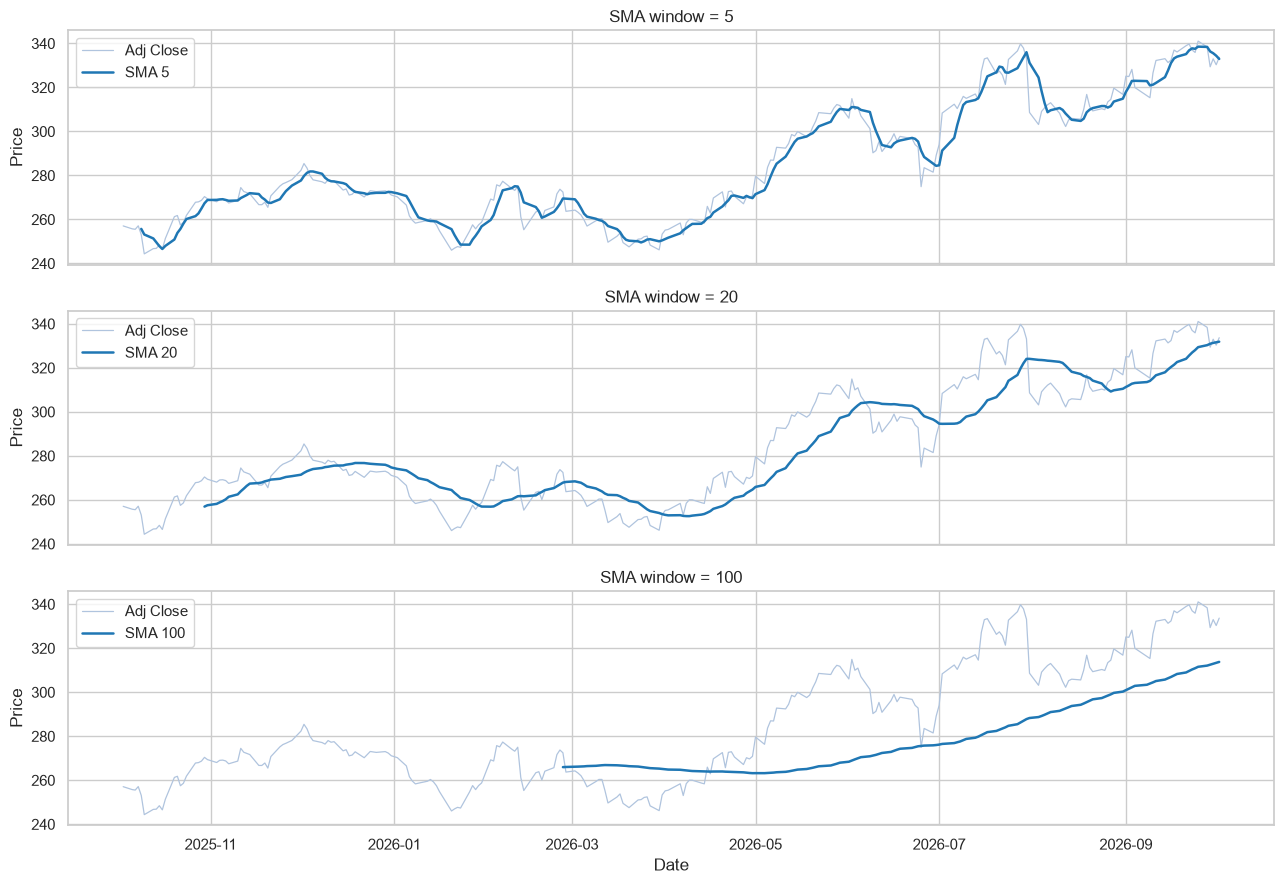

In [4]:
windows = [5, 20, 100]
fig, axes = plt.subplots(len(windows), 1, figsize=(13, 9), sharex=True)
for ax, w in zip(axes, windows):
    ax.plot(close.index, close, color="lightsteelblue", linewidth=0.9, label="Adj Close")
    ax.plot(close.index, sma(close, w), color="tab:blue", linewidth=1.8, label=f"SMA {w}")
    ax.set_ylabel("Price")
    ax.legend(loc="upper left")
    ax.set_title(f"SMA window = {w}")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 4. Golden cross & death cross

A **crossover** happens when the fast 50-day SMA crosses the slow 200-day SMA:

- **Golden cross**: `SMA50` crosses *above* `SMA200` → the medium trend has overtaken the long
  trend. Often read as bullish.
- **Death cross**: `SMA50` crosses *below* `SMA200` → bearish.

We detect them as **sign changes** of the series `SMA50 - SMA200`: today the difference is on
one side of zero, yesterday it was on the other. `shift(1)` gives us yesterday's value.

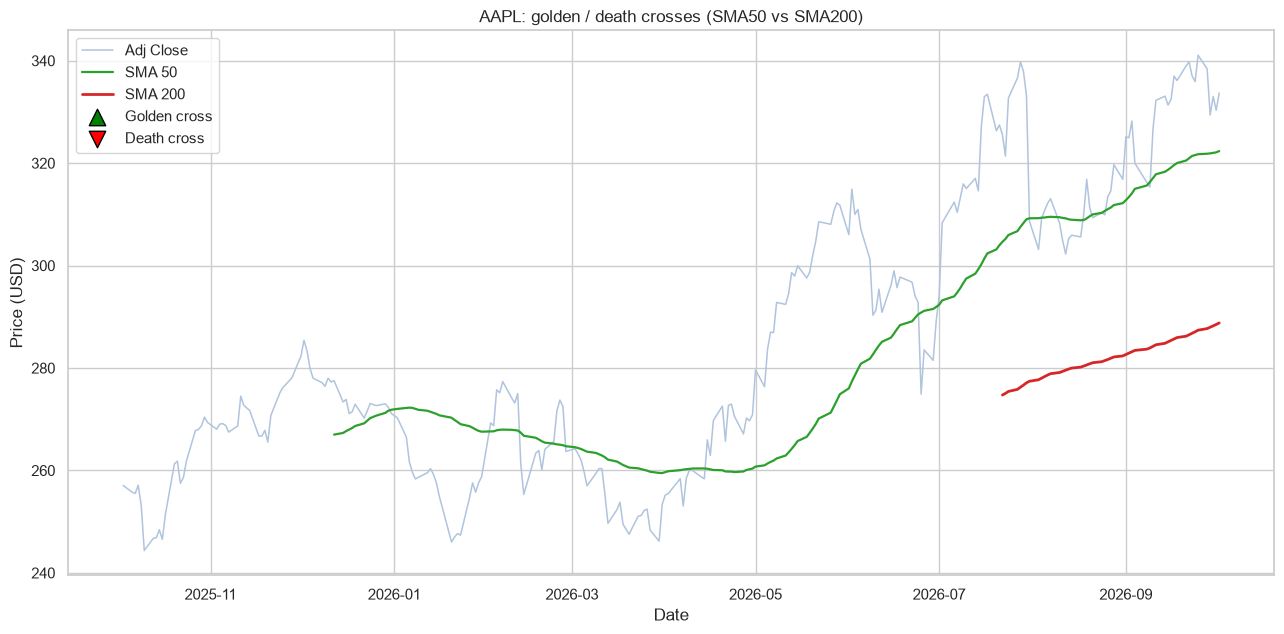

Golden crosses: []
Death crosses:  []


In [5]:
diff = sma50 - sma200

golden = (diff > 0) & (diff.shift(1) <= 0)
death = (diff < 0) & (diff.shift(1) >= 0)

x_alt = close.index
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(x_alt, close, color="lightsteelblue", linewidth=1.1, label="Adj Close")
ax.plot(x_alt, sma50, color="tab:green", linewidth=1.6, label="SMA 50")
ax.plot(x_alt, sma200, color="tab:red", linewidth=2.0, label="SMA 200")

ax.scatter(x_alt[golden], close[golden], marker="^", s=140, color="green",
           edgecolor="black", zorder=5, label="Golden cross")
ax.scatter(x_alt[death], close[death], marker="v", s=140, color="red",
           edgecolor="black", zorder=5, label="Death cross")

for ts in x_alt[golden]:
    ax.annotate("golden", (ts, close.loc[ts]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=8, color="green")
for ts in x_alt[death]:
    ax.annotate("death", (ts, close.loc[ts]), textcoords="offset points",
                xytext=(0, -20), ha="center", fontsize=8, color="red")

ax.set_title(f"{ticker}: golden / death crosses (SMA50 vs SMA200)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

print("Golden crosses:", list(golden[golden].index.strftime("%Y-%m-%d")))
print("Death crosses: ", list(death[death].index.strftime("%Y-%m-%d")))


## What a crossover does — and does not — imply

**It does:** confirm that the medium-term average trend has flipped relative to the long-term
one. It is a *descriptive* statement about the past few months of prices.

**It does not:** predict the future. Two big caveats:

1. **Lag.** Both averages are backward-looking, so a cross is confirmed only *after* much of the
   move has happened. The 200-day average alone needs 200 bars to exist.
2. **Whipsaws.** In a sideways market the two lines braid around each other and produce
   repeated, contradictory crosses that each lose money after costs. Crossovers work best in
   sustained trends and are near-useless in chop.

That is why professionals combine a trend filter like this with momentum (RSI/MACD) and
volatility measures — no single average is a trading system.

## Recap / try this
1. Change `ticker` to `"MSFT"` or `"SPY"` and rerun — do the same cross dates appear?
2. Change `period = "5y"` (or `"max"`). With more history the 200-day SMA is defined from the
   start and you will see many more golden/death crosses — evidence of whipsaw.
3. Try `ema(close, 50)` vs `ema(close, 200)` for the cross detection: do EMA crosses fire
   earlier or later than SMA crosses? Are there more or fewer of them?
4. Replace the 50/200 pair with 20/50 to see how a faster pair gives many more, noisier signals.
